In [36]:
#conda create -n upscaler python=3.11 -y
#conda activate upscaler
#conda install -c conda-forge notebook
#Real-ESRGAN is a deep-learning-based super-resolution model that uses Generative Adversarial Networks (GANs) to enhance and upscale real-world images.

In [37]:
import numpy as np
import torch

print("NumPy:", np.__version__)
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

from realesrgan import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet

print("Real-ESRGAN OK ✅")

NumPy: 1.26.4
Torch: 2.1.2+cu121
CUDA: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Real-ESRGAN OK ✅


In [38]:
import os
import urllib.request

# Create weights folder
os.makedirs("weights", exist_ok=True)

# Download model
url = "https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth"
path = "weights/RealESRGAN_x4plus.pth"

#Check if file already exists
if not os.path.exists(path):
    print("Downloading model...")
    urllib.request.urlretrieve(url, path)
    print("Download complete ✅")
else:
    print("Model already exists ✅")

print("Saved at:", path)

Model already exists ✅
Saved at: weights/RealESRGAN_x4plus.pth


In [49]:
import torch
import cv2
from PIL import Image
from realesrgan import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet


def upscale_realesrgan(
    input_path,
    output_path,
    scale=4,
    weights_path="weights/RealESRGAN_x4plus.pth"
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    # Build model architecture
    model = RRDBNet(
        num_in_ch=3,
        num_out_ch=3,
        num_feat=64,
        num_block=23,
        num_grow_ch=32,
        scale=scale
    )

    # Create upscaler
    upsampler = RealESRGANer(
        scale=scale,
        model_path=weights_path,
        model=model,
        tile=0,
        tile_pad=10,
        pre_pad=0,
        half=torch.cuda.is_available(),
        device=device
    )

    # Load image (OpenCV format)
    img = cv2.imread(input_path)

    # Upscale
    output, _ = upsampler.enhance(img, outscale=scale)

    # Save
    cv2.imwrite(output_path, output)

    return output_path

In [50]:
input_path = "weights/low-quality.png"              # put your file name here
upscaled_path = "output_upscaled.png" # output

upscale_realesrgan(input_path, upscaled_path)
print("Saved:", upscaled_path)

Device: cuda
Saved: output_upscaled.png


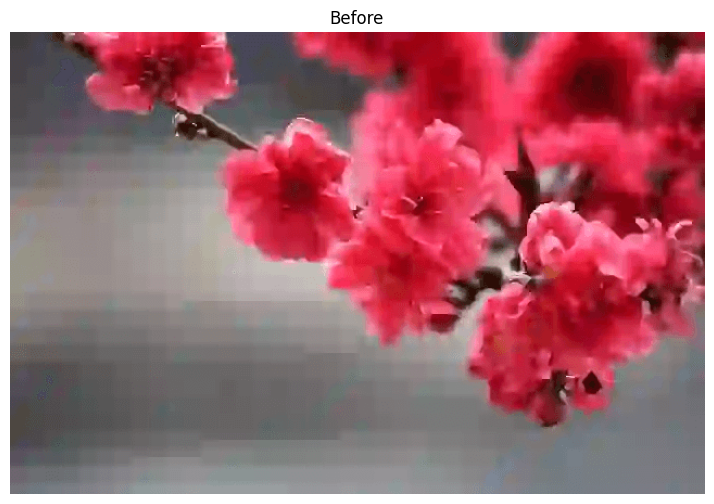

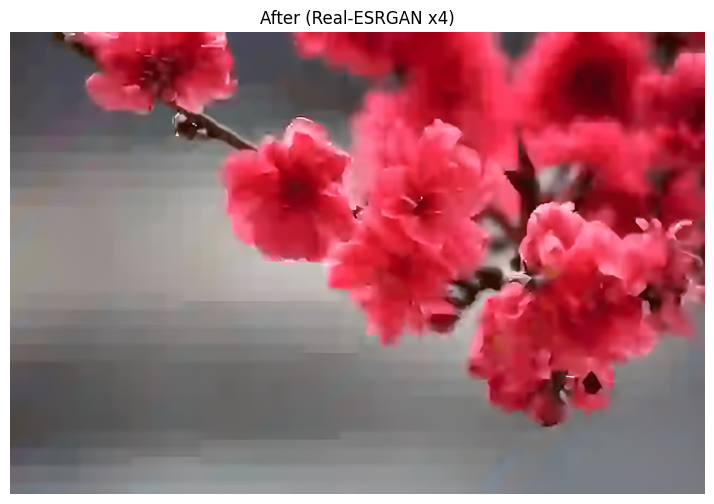

In [51]:
import matplotlib.pyplot as plt

before = Image.open(input_path).convert("RGB")
after = Image.open(upscaled_path).convert("RGB")

plt.figure(figsize=(14,6))
plt.imshow(before)
plt.title("Before")
plt.axis("off")
plt.show()

plt.figure(figsize=(14,6))
plt.imshow(after)
plt.title("After (Real-ESRGAN x4)")
plt.axis("off")
plt.show()

In [52]:
!git add .
    

In [53]:
!git commit -m "Add Real ESRGAN model "

[main 44fde1b] Add Real ESRGAN model
 5 files changed, 166 insertions(+), 27 deletions(-)
 create mode 100644 output_upscaled.png
 create mode 100644 weights/Audrey_Hepburn.jpg
 create mode 100644 weights/RealESRGAN_x4plus.pth
 create mode 100644 weights/low-quality.png


In [58]:
!git remote -v

origin	https://github.com/supun-pregeeth/deep-image-upscaler.git (fetch)
origin	https://github.com/supun-pregeeth/deep-image-upscaler.git (push)


In [60]:
!git push

fatal: unable to access 'https://github.com/supun-pregeeth/deep-image-upscaler.git/': Recv failure: Connection was reset
